In [16]:
import jax.numpy as jnp
import numpy as np
import jax

from jax import Array
from jax.typing import ArrayLike
from typing import Optional

from jaxopt import ProjectedGradient
from jaxopt.projection import projection_simplex

#import jax_dataloader as jdl
#from typing import Any, Callable, final
#from typing_extensions import override

import matplotlib.pyplot as plt
import os

#jax.config.update("jax_enable_x64", True)
#XLA_PYTHON_CLIENT_PREALLOCATE=False


Set directories as needed

In [5]:
fig_dir = "/mnt/home/levans/ensemble_reweighting/parsimonious_ensembles/figures/igg"
#os.makedirs(fig_dir)

Load likelihood matrix data

In [ ]:
data_directory = "/mnt/home/levans/ceph/cryo_reweighting_examples/latent_example"
zdim=2
log_likelihood = -1*np.load(f"{data_directory}/log_likelihood_zs_subset_{zdim}.npy").astype('float16')
zs = np.load(f"{data_directory}/zs_subset_{zdim}.npy").astype('float16')

In [10]:
num_images, num_nodes = log_likelihood.shape
print(f"{num_images} images, {num_nodes} nodes")

90000 images, 9000 nodes


# Define diagnostics shared across methods

In [11]:
@jax.jit
def grad_log_prob(weights: ArrayLike, likelihood: ArrayLike) -> Array:
    model = jnp.sum(likelihood*weights, axis=1)
    grad = jnp.mean(likelihood/model[:, jnp.newaxis], axis=0) 
    return grad

@jax.jit
def grad_log_prob_in_log_space(weights,log_likelihood):
    num_images, num_structures = log_likelihood.shape

    log_density_at_weights = jax.scipy.special.logsumexp(a=log_likelihood, b=weights, axis=1)
    aux = log_likelihood - log_density_at_weights.reshape(num_images, 1)
    grad =  (1/num_images)*(jnp.exp(jax.scipy.special.logsumexp(aux, axis=0)))
    return grad

@jax.jit
def compute_loss(weights: ArrayLike, likelihood: ArrayLike) -> Array:
    loss = -jnp.mean(jnp.log(jnp.sum(likelihood*weights, axis=1)))
    return loss

@jax.jit
def compute_loss_in_log_space(weights: ArrayLike, log_likelihood: ArrayLike) -> Array:
    loss = -jnp.mean(jax.scipy.special.logsumexp(a=log_likelihood, b=weights[None, :], axis=1))
    return loss

@jax.jit
def update_stats(weights: ArrayLike, likelihood: ArrayLike):
    loss = compute_loss(weights, likelihood)
    return loss



# Defining methods with regularization options

In [28]:
@jax.jit
def update_weights_multiplicative_gradient_reg(weights: ArrayLike, grad: ArrayLike, reg=1.0) -> Array:
    weights = weights*(grad - reg*jnp.log(weights))
    weights /= jnp.sum(weights) 
    return weights

@jax.jit
def update_weights_multiplicative_gradient(weights: ArrayLike, grad: ArrayLike) -> Array:
    weights = weights*grad
    return weights

def gradient_simplex(
    log_likelihood: ArrayLike,
    tol: Optional[float] = 1e-8,
    max_iterations: Optional[float] = 100000,
    verbose: Optional[bool]=False,
    iter_freq: Optional[int] = 100,
    weights_init=None,
    reg =0.0,
):

    num_images, num_structures = log_likelihood.shape

    # Initialize Weights
    if weights_init == None:
        weights = (1/num_structures)*jnp.ones(num_structures)

    else:
        weights = weights_init
    # Subtracting the largest entry from each row of likelihood
    # The gradient is invariant to row scaling of likelihood, so this is valid
    # With this, we avoid working in log space for the grad and loss
    log_likelihood_aux = log_likelihood - jnp.max(log_likelihood, 1)[:, jnp.newaxis]
    
    # NOTE: we cannot exponentiate this if previous step hasn't happened 
    likelihood = jnp.exp(log_likelihood_aux)
    
    # Iterate
    stats = {}
    stats["loss"] = []
    stats["gap"] = []
    stats["weights"] = []
    stats["weights_idx"] = []
    stats["weights_error"] = []
    for k in range(max_iterations):

        # Update weights
        grad = grad_log_prob(weights, likelihood)
        #grad = grad_log_prob_in_log_space(weights, log_likelihood)

        if reg > 0.0:
            weights = update_weights_multiplicative_gradient_reg(weights, grad, reg)
        else:
            weights = update_weights_multiplicative_gradient(weights, grad)
 
        # update per iteration stats
        loss  = update_stats(weights, likelihood)
        # Check stopping criterion: this `gap` is an upper bound on our loss compared to optimal weights
        gap = jnp.max(grad) - 1
        if k % iter_freq == 0: 
            if verbose:
                print(f"Number of iterations:{k}")
                print(f"Gap: {gap}") 
            stats["weights"].append(weights)
            stats["weights_idx"].append(k)
        if gap < tol:
            print(f"Number of iterations: {k}")
            print("exiting!")
            break

        stats["loss"].append(loss)
        stats["gap"].append(gap)


    stats["gap"] = jnp.stack(stats["gap"])
    stats["weights"] = jnp.stack(stats["weights"])
    stats["loss"] = jnp.stack(stats["loss"])
    stats["weights_idx"] = jnp.stack(stats["weights_idx"])
    return weights, stats

In [29]:
def plot_weights(zs, ensemble_weights, coords, xbounds=None, ybounds=None, vmin=None, vmax=None):
    plt.figure()
    if vmin==None or vmax==None:
        plt.scatter(zs[:, coords[0]], zs[:, coords[1]], c=ensemble_weights, s=5, cmap="inferno")
    else: 
        plt.scatter(zs[:, coords[0]], zs[:, coords[1]], c=ensemble_weights, s=5, cmap="inferno", vmin=vmin, vmax=vmax)
    
    if xbounds is not None: 
        plt.xlim(xbounds)
        plt.ylim(ybounds)
    plt.xlabel("PC 0")
    plt.ylabel(f"PC {1}")
    plt.colorbar()
    plt.tight_layout()
    plt.savefig("test.png")
    

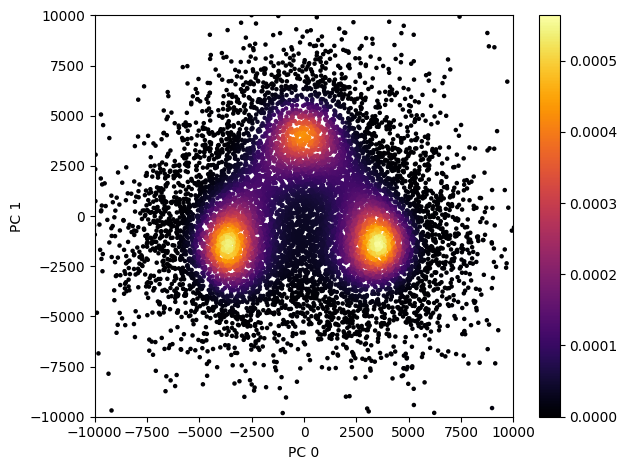

In [33]:
results = {}

ensemble_weights, stats = gradient_simplex(log_likelihood, max_iterations=1000, iter_freq=1, tol=-1, reg=0.01)
results[METHOD] = {"ensemble_weights":ensemble_weights, "stats":stats}
gap_mult = results[METHOD]["stats"]["gap"]
loss_mult = results[METHOD]["stats"]["loss"]

#vmin = jnp.amin(ensemble_weights)
#vmax = jnp.amax(ensemble_weights)

#plot_weights(zs, ensemble_weights, xbounds, ybounds)
xbounds = [-10000, 10000]
ybounds = [-10000, 10000]
plot_weights(zs, ensemble_weights, coords=[0,1], xbounds=xbounds, ybounds=ybounds)
#plot_weights(zs, ensemble_weights, coords=[0, 1])
import matplotlib
#plt.scatter(zs[:, -1], zs[:, -2], c=ensemble_weights, s=1, norm=matplotlib.colors.LogNorm(vmin=1E-10, vmax=1E-1), cmap='inferno')


# Trying nearest neighbors smoothing

In [ ]:
#from sklearn.neighbors import RadiusNeighborsRegressor
#neigh = RadiusNeighborsRegressor(radius=500)
from sklearn.neighbors import KNeighborsRegressor
neigh = KNeighborsRegressor(n_neighbors=1000)
neigh.fit(zs[:, 0:2], ensemble_weights)
smoothed_weights = neigh.predict(zs[:, 0:2])
smoothed_weights /= np.sum(smoothed_weights)



/mnt/home/levans/venvs/ensemble_sim/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


ValueError: Input X contains infinity or a value too large for dtype('float16').

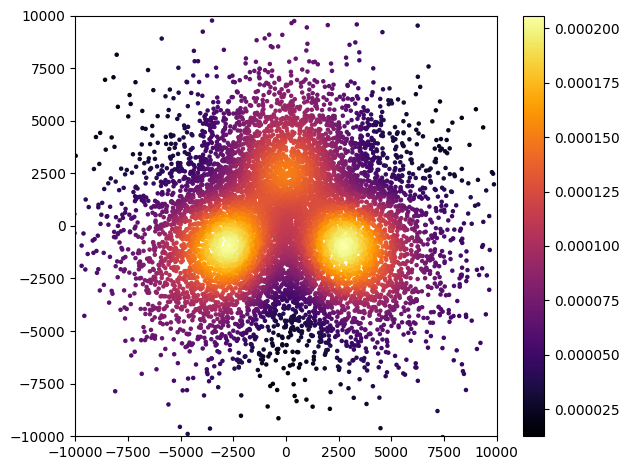

: 

: 

: 

: 

: 

...

: 

: 

: 

: 

: 

In [ ]:
#plot_weights(zs, smoothed_weights)
plt.scatter(zs[:, 0], zs[:, 1], c=smoothed_weights, s=5, cmap="inferno")
#plt.xlim(xbounds)
#plt.ylim(ybounds)
#plt.xlabel("PC 0")
#plt.ylabel(f"PC {1}")
plt.colorbar()
plt.tight_layout()
#plt.savefig("test.png")
plt.xlim([-10000, 10000])
plt.ylim([-10000, 10000])
plt.tight_layout()



In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
#nbrs = NearestNeighbors(n_neighbors=50, algorithm='ball_tree').fit(zs[:, 1:3])
#distances, indices = nbrs.kneighbors(zs[:, 0:2])

#nbrs = NearestNeighbors(radius=500, algorithm='ball_tree').fit(zs[:, 0:2])
#A = nbrs.radius_neighbors_graph(zs[:, 0:2]).toarray().astype('bool')
##@jax.jit
##def smoothing(indices, weights):
##    smoothed = np.zeros_like(weights)
##    for j in range(len(weights)):
##        smoothed[j] = np.mean(weights[indices[j, :]])
##    return smoothed
##smoothed = smoothing(indices, ensemble_weights)
#smoothed = np.zeros_like(ensemble_weights)
#@jax.jit
#def smoothing(A, weights):
#    for j in range(len(weights)):
#        indices = A[j, :]
#        #print(np.count_nonzero(indices))
#        smoothed[j] = np.sum(weights[indices])/np.count_nonzero(indices)
#        #smoothed[j] = np.mean(weights[indices])
#    return smoothed
#smoothed = smoothing(A, ensemble_weights)

: 

: 

: 

: 

: 

...

: 

: 

: 

: 

: 

# Trying a smoother on a histogram

/mnt/home/levans/venvs/ensemble_sim/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:57: RuntimeWarning: overflow encountered in multiply
  return bound(*args, **kwds)


(99, 99)


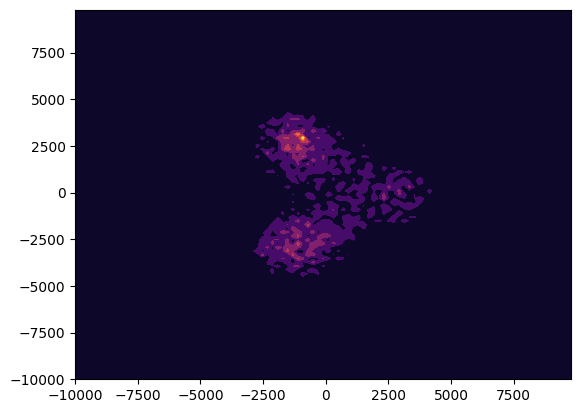

: 

: 

: 

: 

: 

...

: 

: 

: 

: 

: 

In [ ]:
from scipy.stats import binned_statistic_dd
x = jnp.linspace(-10000,10000, 100)
y = jnp.linspace(-10000,10000, 100)
ret = binned_statistic_dd(zs[:, 0:2], ensemble_weights, bins=[x,y], statistic='sum')
bincounts = ret.statistic
print(np.shape(bincounts))
#dx = x[1] - x[0]
#dy = y[1] - y[0]
X, Y = jnp.meshgrid(x[:-1],y[:-1])
plt.contourf(X,Y, bincounts, cmap='inferno')
#fig = plt.figure()
#ax = fig.add_subplot(111, projection="3d")
#with np.errstate(divid='ignore'):
#    ax.bar3D

In [ ]:
plot_weights(zs[:, [0, 1]], smoothed)
plt.xlim([-10000, 10000])
plt.ylim([-10000, 10000])

NameError: name 'smoothed' is not defined

: 

: 

: 

: 

...

: 

: 

: 

: 

: 

0.21452355


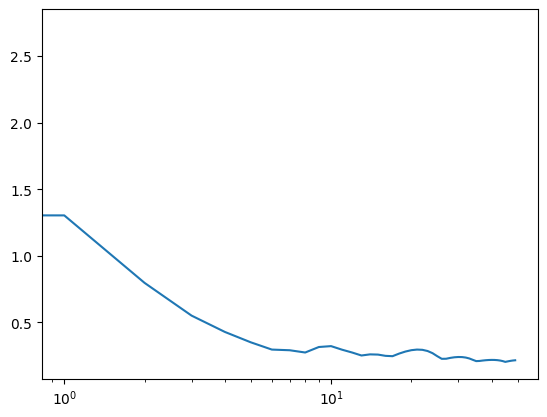

: 

: 

: 

: 

: 

...

: 

: 

: 

: 

: 

In [ ]:
plt.figure()
plt.semilogx(gap_mult)
#plt.semilogx(loss_mult)
print(gap_mult[-1])

In [ ]:
from scipy.spatial.distance import pdist, squareform
from scipy.stats import gaussian_kde

kde = gaussian_kde(zs[:, 0:2].T, bw_method='silverman')
bw = kde.silverman_factor()
dist = squareform(pdist(zs[:, 0:2], 'euclidean'))
kernel = np.exp(-dist**2 / (2*bw))
kernel = np.matmul(np.diag(kernel.sum(axis=0)**(-1)), kernel)
smoothed_weights = np.matmul(kernel,ensemble_weights)

: 

: 

: 

: 

: 

...

: 

: 

: 

: 

: 

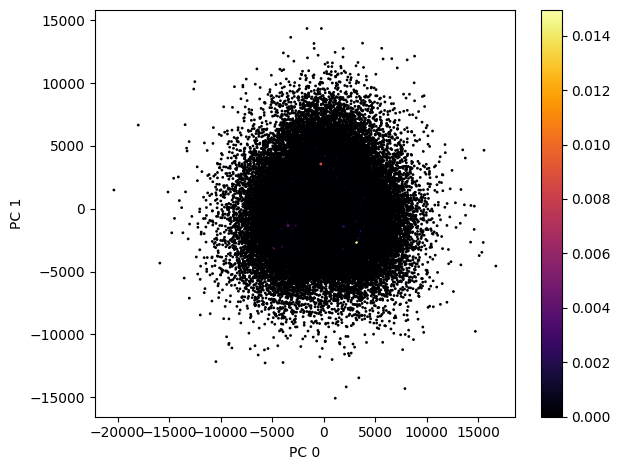

: 

: 

: 

: 

: 

...

: 

: 

: 

: 

: 

In [ ]:
plot_weights(zs, smoothed_weights)

# Projected Gradient

In [ ]:
#log_likelihood = log_likelihood - jnp.max(log_likelihood, 1)[:, jnp.newaxis]
#likelihood = jnp.exp(log_likelihood)
## retrieve intermediate iterates.
## from jaxopt examples page https://jaxopt.github.io/stable/auto_examples/fixed_point/plot_anderson_accelerate_gd.html#sphx-glr-auto-examples-fixed-point-plot-anderson-accelerate-gd-py
#def run_all(solver, w_init, *args, **kwargs):
#  state = solver.init_state(w_init, *args, **kwargs)
#  sol = w_init
#  sols, errors = [], []
#
#  @jax.jit
#  def jitted_update(sol, state):
#    return solver.update(sol, state, *args, **kwargs)
#
#  for _ in range(solver.maxiter):
#    sol, state = jitted_update(sol, state)
#    sols.append(sol)
#    errors.append(state.error)
#
#  return jnp.stack(sols, axis=0), errors
#
#w_init = jnp.ones(log_likelihood.shape[1]) / log_likelihood.shape[1]
##eta = 1e-1  # small step size
##l2reg = 0.  # no regularization
##tol = 1e-5
##maxiter = 80
#pg = ProjectedGradient(fun=compute_loss_in_log_space, projection=projection_simplex, maxiter=100) 
#pg_sols, pg_errors = run_all(pg, w_init, log_likelihood=log_likelihood)

: 

: 

: 

: 

: 

...

: 

: 

: 

: 

: 

In [ ]:
#pg_losses = []
#for i in range(len(pg_sols)):
#    pg_losses.append(compute_loss_in_log_space(pg_sols[i], log_likelihood))
#
#pg_losses = jnp.stack(pg_losses)
#pg_errors = jnp.stack(pg_errors)
#plt.plot(pg_losses)
#plt.plot(loss_mult)
##w_init = jnp.ones(log_likelihood.shape[1]) / log_likelihood.shape[1]
#weights_op = pg_sols[-1]
#plot_weights(zs,weights_op, xbounds, ybounds, vmin=jnp.min(weights_op), vmax=jnp.max(weights_op))

: 

: 

: 

: 

: 

...

: 

: 

: 

: 

: 

# Interior Point solver

In [ ]:
#import cvxpy as cvx
# 
## NOTE: this one just doesn't work right now, likely due to that it uses an exponential of the log_Pij(?)
#def solve_cvx_weights(log_Pij, log_weights_init=None):
#    """
#    Code almost directly from https://github.com/jake-soloff/NPEB/blob/master/npeb/GLMixture.py
#    """
#    num_data, num_nodes = log_Pij.shape
#
#    # Normalize rows of log_Pij for stability
#    log_Pij -= jnp.amax(log_Pij, 1)[:, jnp.newaxis]
#    Pij = jnp.exp(log_Pij)
#    
#    w = cvx.Variable(num_nodes)
#    constraints = [w >= 0, cvx.sum(w) == 1]
#    obj = cvx.Maximize(cvx.sum(cvx.log(Pij @ w)))
#    prob = cvx.Problem(obj, constraints)
#    print("using default solver in cvxpy for now, with full outputs of optimization")
#    prob.solve(verbose=True)
#    return w.value
#solve_cvx_weights(log_likelihood)


: 

: 

: 

: 

: 

...

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

...

: 

: 

: 

: 

: 